# Imports:

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
from ase.visualize import view
import seaborn as sns
col_list = sns.color_palette("tab10", 100)

from aq_gnome.data_handler import Data_Handler
from aq_gnome import (
    plot_periodic_table_with_values, get_col_dict_for_atoms,
    Stable_Entries, Stability_Criteria, get_simplified_df,
    atoms_from_db, sys_in_MP_db,
)

# pHs = np.linspace(-2, 16, 19) # Data specific
# Us = np.linspace(-2, 4, 31) # Data specific

# Database setup:

In [17]:
# Define directory of data (can be left as None if the data folder is in
# the package root):
dir_of_data = None

dh = Data_Handler(
# Whether to apply solid filter:
    solid_filter = True,
# Whether to use only GGA calculations (True), or include r2SCAN data via the MP-mixing scheme (False):
    gga_only = False,
# Path to data directory:
    path_to_data_directory = dir_of_data
    )

# Inclusion/exclusion of elements:

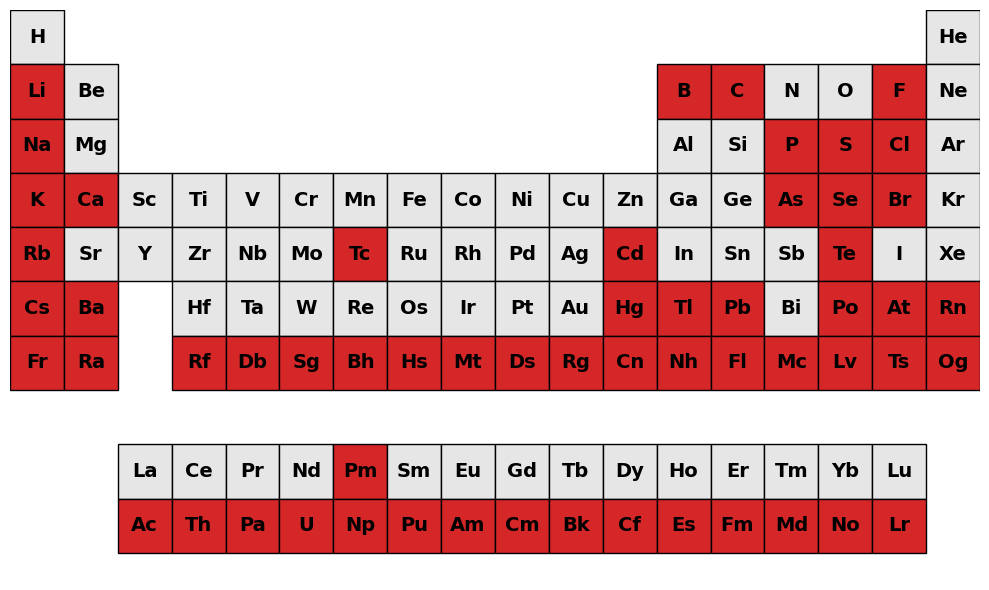

In [18]:
radioactive_elements = ['Tc',  'Ra', 'Rf', 'Db', 'Sg', 'Bh', 'Hs',
                        'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv',
                        'Ts', 'Og', 'Pm', 'Ac', 'Th', 'Pa', 'U', 'Np',
                        'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md',
                        'No', 'Lr', 'Po', 'At', 'Rn'
                        ]

reactive_with_water_elements = ['Li', 'Na', 'K', 'Rb', 'Cs', 'Fr', 'Ca', 'Ba']

toxic_elements = ['Tl', 'Pb', 'As', 'Cd', 'Hg']

too_rare_elements = ['Be', 'Y', 'Nb', 'Rh', 'Pd', 'Te', 'Sb', 'Lu', 'Re',
                    'Os', 'Pt', 'Hg', 'Bi', 'La', 'Ce', 'Pr', 'Nd', 'Pm',
                    'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb',
                    'Ru', 'Ir']


CMR = [
    'Be', 'B', 'Si', 'Sc', 'Ti', 'V', 'Co', 'Ga', 'Ge', 'Cr', 'Y', 'Nb',
    'Ru', 'Rh', 'Pd', 'Sb', 'Lu', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt', 'Bi',
    'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd',
    'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb'
]

platinum_group = ['Ru', 'Rh', 'Pd', 'Os', 'Ir', 'Pt']


elements_to_exclude = radioactive_elements + toxic_elements + reactive_with_water_elements + ['Br', 'C', 'F', 'Se', 'Te', 'B', 'P', 'S', 'Cl'] # + ['S', 'C', 'Cl', 'P', 'B', 'Bi']
 # + higly_concentrated_elements  # elements to discart
elements_whic_must_be_included = []

plot_periodic_table_with_values(
    get_col_dict_for_atoms(elements_to_discard=elements_to_exclude,
                           elements_to_include=elements_whic_must_be_included)
)

### Discarding materials based on element selection

In [19]:
dh.restore_df()
dh.remove_entries_with_elements(elements_to_exclude)
# dh.remove_entries_without_elements(elements_whic_must_be_included, False)
# dh.remove_entries_without_elements(['Li', 'Na', 'K'], False)

Number of entries removed: 289367 Number of entries left: 239604 which is 45.30% of total GNoME database


### pbx stability criteria

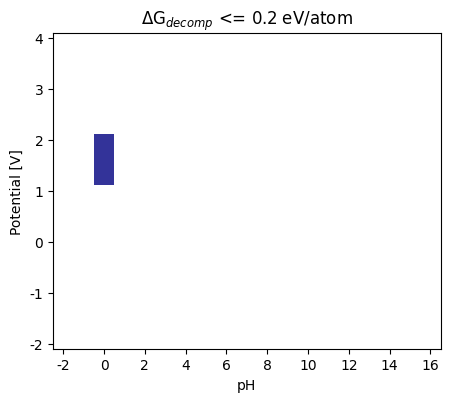

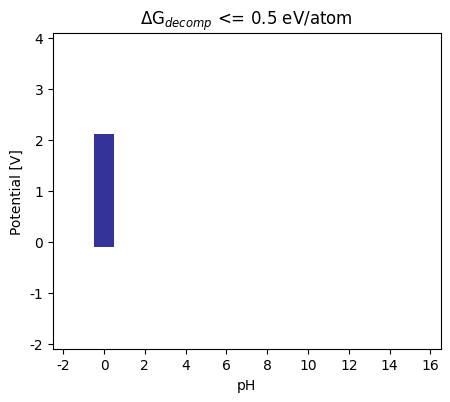

In [20]:
SCS = [
    Stability_Criteria(pHs=[0], Us=[1.2, 2], decomposition_threshold=0.2),
    Stability_Criteria(pHs=[0], Us=[0, 2], decomposition_threshold=0.5),
       # Stability_Criteria(pHs=0, Us=[1.2, 1.6], decomposition_threshold=0.05),
       # Stability_Criteria(pHs=[2, 5], Us=[0., 2], decomposition_threshold=1),
       ]

for sc in SCS:
    sc.visualize()

In [21]:
se = Stable_Entries(dh, SCS)
se.get_stable_df()

Mixed GGA/GGA(+U)/r2SCAN results will be used for stability analysis.


100%|██████████| 239604/239604 [01:30<00:00, 2639.68it/s]


Found 924 stable entries given the stability criteria.


,"max_dG_U[1.2,2]_pH0","max_dG_U[0,2]_pH0",Composition,MaterialId,Reduced Formula,Elements,NSites,Volume,Density,Point Group,...,Data Directory,gga_only_pbx_save_id,mixed_pbx_save_id,Disorder Probability,average_HHI_P,average_HHI_R,average_HHI_P_excluding_O_H,average_HHI_R_excluding_O_H,max_HHI_P,max_HHI_R
412,0.20,0.49,Bi3Ir4O14Sr1,0033416f3c,SrBi3(Ir2O7)2,"[O, Sr, Ir, Bi]",22,285.0297,9.9472,-3m,...,gs://crystal-design/output/borg/improved_wy_ro...,GGA_0033416f3c,GGA_0033416f3c,0.804672,2232.0,2927.0,5262.0,7175.0,5500.0,9100.0
562,0.20,0.47,Bi3Er1Ir2O14Rh2,0045bb1a40,ErBi3Ir2(RhO7)2,"[O, Rh, Er, Ir, Bi]",22,277.1457,9.6371,2/m,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_0045bb1a40,GGA_0045bb1a40,0.933969,2264.0,2832.0,5350.0,6912.0,9500.0,9100.0
642,0.18,0.18,Er1Nb2O8Y1,00503ec59b,YErNb2O8,"[O, Y, Nb, Er]",12,151.3070,6.2552,2,...,gs://crystal-design/output/borg/round_3_wy_3/1...,GGA_00503ec59b,GGA_00503ec59b,0.919861,3358.0,2275.0,9075.0,5825.0,9800.0,8800.0
1030,0.05,0.28,Dy2O16Sb4Sc2,007bfa96d2,DySc(SbO4)2,"[O, Sc, Sb, Dy]",24,296.8304,6.4778,-1,...,gs://crystal-design/output/borg/improved_wy_ro...,GGA_007bfa96d2,Not computed,0.940567,2900.0,1533.0,7700.0,3600.0,9500.0,4500.0
1319,0.15,0.25,Fe4Ho3O24Sm1W4,009cee3fd2,SmHo3Fe4(WO6)4,"[O, Fe, Sm, Ho, W]",36,433.7088,7.6110,1,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_009cee3fd2,GGA_009cee3fd2,0.910620,2433.0,1311.0,6300.0,2933.0,9500.0,4300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526598,0.07,0.31,Bi1Dy3Mo6O24,feddc9f9a6,Dy3Bi(MoO4)6,"[O, Mo, Dy, Bi]",34,606.5507,4.5339,m,...,gs://crystal-design/output/borg/round_3_4/1e_3...,GGA_feddc9f9a6,GGA_feddc9f9a6,0.617282,1771.0,1738.0,4820.0,4710.0,9500.0,6000.0
527359,0.14,0.24,Fe4Nd2O24Tb2W4,ff3b944c15,TbNdFe2(WO6)2,"[O, Fe, Nd, Tb, W]",36,444.5165,7.2809,m,...,gs://crystal-design/output/borg/round_3_wy_upd...,GGA_ff3b944c15,GGA_ff3b944c15,0.929936,2433.0,1311.0,6300.0,2933.0,9500.0,4300.0
527729,0.19,0.31,Dy2O14Sb2Sc4,ff699b09c4,DySc2SbO7,"[O, Sc, Sb, Dy]",22,269.3784,5.9938,mmm,...,gs://crystal-design/output/borg/round_3_4/1e_3...,GGA_ff699b09c4,Not computed,0.927245,2900.0,1727.0,7100.0,3875.0,9500.0,4500.0
528628,0.08,0.33,Mo6Nd2O24Pr2,ffd23587b0,PrNd(MoO4)3,"[O, Mo, Pr, Nd]",34,646.1995,3.9314,mm2,...,gs://crystal-design/output/borg/improved_wy_ro...,GGA_ffd23587b0,GGA_ffd23587b0,0.798887,1894.0,1653.0,5240.0,4420.0,9500.0,5300.0


In [24]:
# df = df[df["Disorder Probability"] < 0.2]
# df = df[~df['Reduced Formula'].apply(lambda x: '(SO4)' in x)]

# df = df[~df['Elements'].apply(lambda x: 'F' in x)]

df = se.get_stable_df().copy()

# df = df[df['Elements'].apply(lambda x: any([el in x for el in ['Cn']]))]
# df = df[df['Elements'].apply(lambda x: any([el in x for el in ['Pd']]))]


df = df[df['Dimensionality Cheon'] == '3D']
df = df[df['NSites'] < 40]

# df = df[df['Elements'].apply(lambda x: len(x) <= 4)]

df = df[df['Bandgap'] < 0.05]
# df = df[df['average_HHI_P_excluding_O_H'] < 6000]
# df = df[df['average_HHI_R_excluding_O_H'] < 6000]
# df = df[df['max_HHI_P'] < 6000]
# df = df[df['max_HHI_R'] < 6000]
df = df[df['Disorder Probability'] < 0.5]

# df = get_simplified_df(df)
# df = df.sort_values(by="Bandgap")
# df = df.sort_values(by="HHI_P_excluding_OHCNP")
print(len(df))

df = df.sort_values(by="Bandgap")
get_simplified_df(df)


6


,"max_dG_U[1.2,2]_pH0","max_dG_U[0,2]_pH0",Composition,MaterialId,Reduced Formula,Elements,NSites,Crystal System,Dimensionality Cheon,Bandgap,Disorder Probability,average_HHI_P,average_HHI_R,average_HHI_P_excluding_O_H,average_HHI_R_excluding_O_H,max_HHI_P,max_HHI_R
460531,0.08,0.23,Eu1Ge1O6Sb1,df002afde8,EuGeSbO6,"[O, Ge, Sb, Eu]",9,trigonal,3D,0.0008,0.460490,2856.0,1267.0,7567.0,2800.0,9500.0,3400.0
491347,0.06,0.32,Bi6O18Sb3,edc400bc1c,Bi2SbO6,"[O, Sb, Bi]",27,trigonal,3D,0.0037,0.295423,2389.0,2044.0,6167.0,5133.0,7900.0,6000.0
260966,0.19,0.28,Eu1O26Sb11,7e64af37fe,EuSb11O26,"[O, Sb, Eu]",38,triclinic,3D,0.0042,0.496590,2879.0,1408.0,8033.0,3375.0,9500.0,3400.0
74867,0.12,0.22,Ag1Ce1O18Ta6,242830f475,CeTa6AgO18,"[O, Ag, Ce, Ta]",26,monoclinic,3D,0.0043,0.399877,1288.0,1627.0,3062.0,4162.0,9500.0,4800.0
136402,0.11,0.38,Bi6Ir2O14,41f2259194,Bi3IrO7,"[O, Ir, Bi]",22,triclinic,3D,0.0052,0.035266,2264.0,2782.0,5350.0,6775.0,5500.0,9100.0
328656,0.14,0.47,Bi6O14Pt2,9f2c379c94,Bi3PtO7,"[O, Pt, Bi]",22,triclinic,3D,0.0283,0.017947,2264.0,2782.0,5350.0,6775.0,5500.0,9100.0


In [ ]:
simp = sys_in_MP_db(os.environ["MP_API_KEY"])

df = df[~df['Elements'].apply(lambda x: simp.in_db(x))]
print(len(df))
get_simplified_df(df)

In [ ]:
temp_df = df.copy()

temp_df = temp_df[temp_df['Elements'].apply(lambda x: any([el in x for el in ['Pt']]))]
temp_df = temp_df[temp_df['Elements'].apply(lambda x: any([el in x for el in ['Pd']]))]

temp_df

In [ ]:
get_simplified_df(df.sort_values(by="Disorder Probability"))

In [ ]:
retrive_atoms = atoms_from_db()

view(
retrive_atoms.get_atoms_objects_from_df(df.sort_values(by="average_HHI_P_excluding_OHCNPS"))
)

In [ ]:
df.sort_values(by="average_HHI_P_excluding_OHCNPS")